# Importar la libreria panda

In [1]:
import pandas as pd

# Leer el dataset

In [2]:
data = pd.read_csv('housing/housing.csv')

In [3]:
data.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [7]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Gráfica Histograma

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

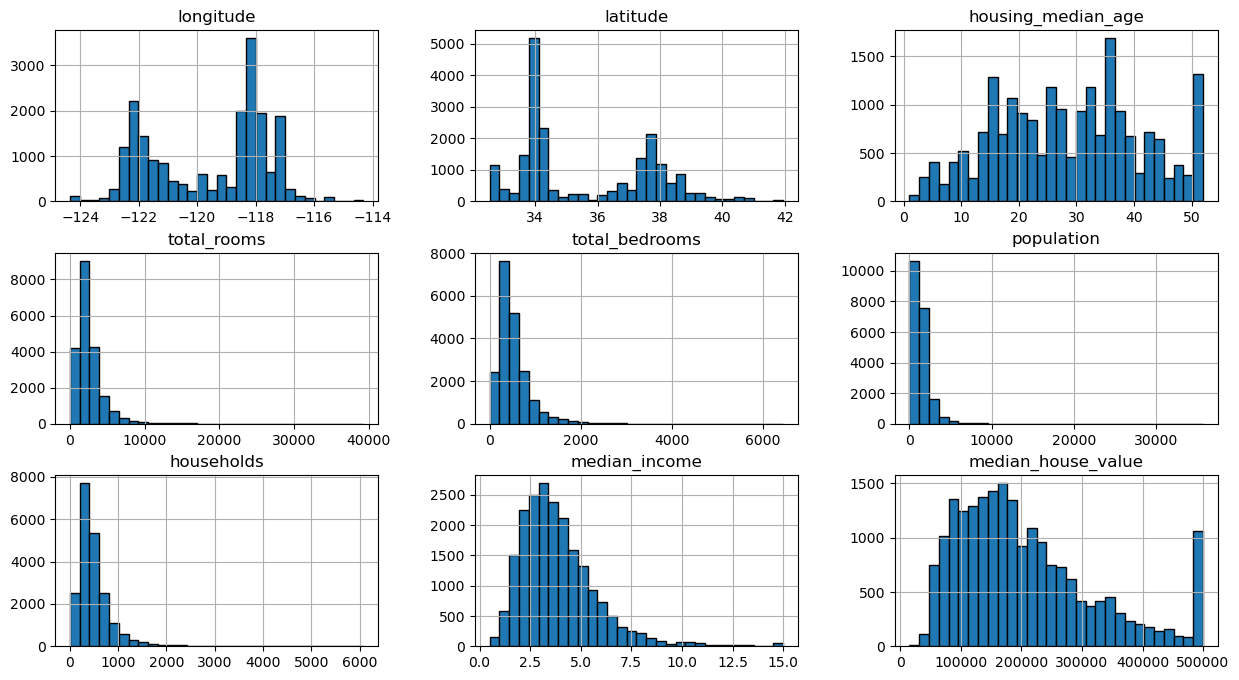

In [8]:
data.hist(bins=30, figsize=(15,8), edgecolor='black')

# Gráfica mapa de calor

<Axes: xlabel='latitude', ylabel='longitude'>

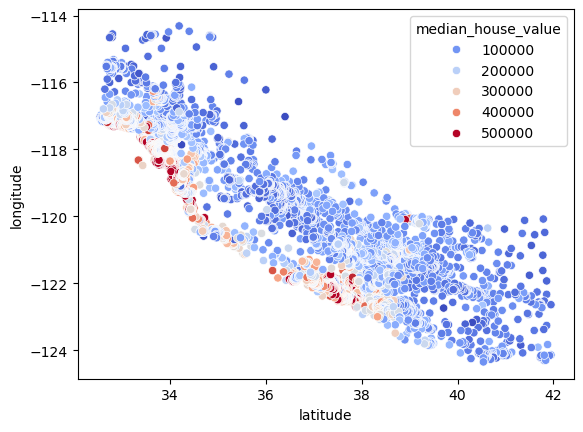

In [9]:
import seaborn as sb
sb.scatterplot(x='latitude', y='longitude', data=data, hue='median_house_value', palette='coolwarm')

<Axes: xlabel='latitude', ylabel='longitude'>

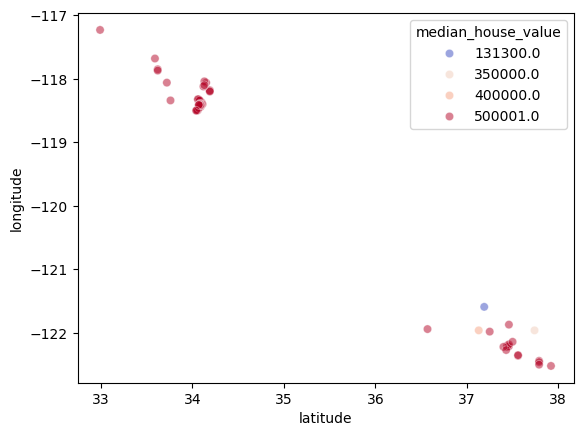

In [10]:
# Filtering the data to only include records where median_income is greater than 14
# Filtrando los datos para incluir solo registros donde median_income es mayor a 14
sb.scatterplot(x='latitude', y='longitude', data=data[(data.median_income > 14)], hue='median_house_value', palette='coolwarm', alpha=0.5)

# Dropear datos NA

In [11]:
data_na = data.dropna()

In [12]:
data_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


# Convertir característica categórica (streing) a numérica

In [13]:
# Proximidad al océano
data_na['ocean_proximity']

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 20433, dtype: object

In [14]:
data_na['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

## Dummies / One-Hot Encoding

In [15]:
# INLAND      NEAR OCEAN      NEAR BAY        ISLAND
#   1           0               0               0
#   0           0               0               1
#   0           0               1               0
#   0           1               0               0

dummies = pd.get_dummies(data_na['ocean_proximity'], dtype=int)

In [16]:
data_na = data_na.join(dummies)

In [17]:
data_na.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0,0,0,1,0


In [18]:
data_na = data_na.drop(['ocean_proximity'], axis=1)

In [19]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Análisis de nuevas características

In [20]:
data_na.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
longitude,1.000000,-0.924616,-0.109357,0.045480,0.069608,0.100270,0.056513,-0.015550,-0.045398,0.320831,-0.055337,0.009501,-0.474714,0.046185
latitude,-0.924616,1.000000,0.011899,-0.036667,-0.066983,-0.108997,-0.071774,-0.079626,-0.144638,-0.446928,0.351084,-0.016662,0.358785,-0.161342
housing_median_age,-0.109357,0.011899,1.000000,-0.360628,-0.320451,-0.295787,-0.302768,-0.118278,0.106432,0.045553,-0.236968,0.017105,0.256149,0.020797
total_rooms,0.045480,-0.036667,-0.360628,1.000000,0.930380,0.857281,0.918992,0.197882,0.133294,-0.003777,0.026477,-0.007603,-0.023647,-0.008674
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,0.018314,-0.006463,-0.004361,-0.019873,0.000679
population,0.100270,-0.108997,-0.295787,0.857281,0.877747,1.000000,0.907186,0.005087,-0.025300,0.073450,-0.019602,-0.010451,-0.061480,-0.023498
households,0.056513,-0.071774,-0.302768,0.918992,0.979728,0.907186,1.000000,0.013434,0.064894,0.041883,-0.038265,-0.009119,-0.011280,0.002106
median_income,-0.015550,-0.079626,-0.118278,0.197882,-0.007723,0.005087,0.013434,1.000000,0.688355,0.168715,-0.237536,-0.009281,0.056677,0.027351
median_house_value,-0.045398,-0.144638,0.106432,0.133294,0.049686,-0.025300,0.064894,0.688355,1.000000,0.257614,-0.484787,0.023525,0.160526,0.140378
<1H OCEAN,0.320831,-0.446928,0.045553,-0.003777,0.018314,0.073450,0.041883,0.168715,0.257614,1.000000,-0.607778,-0.013928,-0.314721,-0.342018


<Axes: >

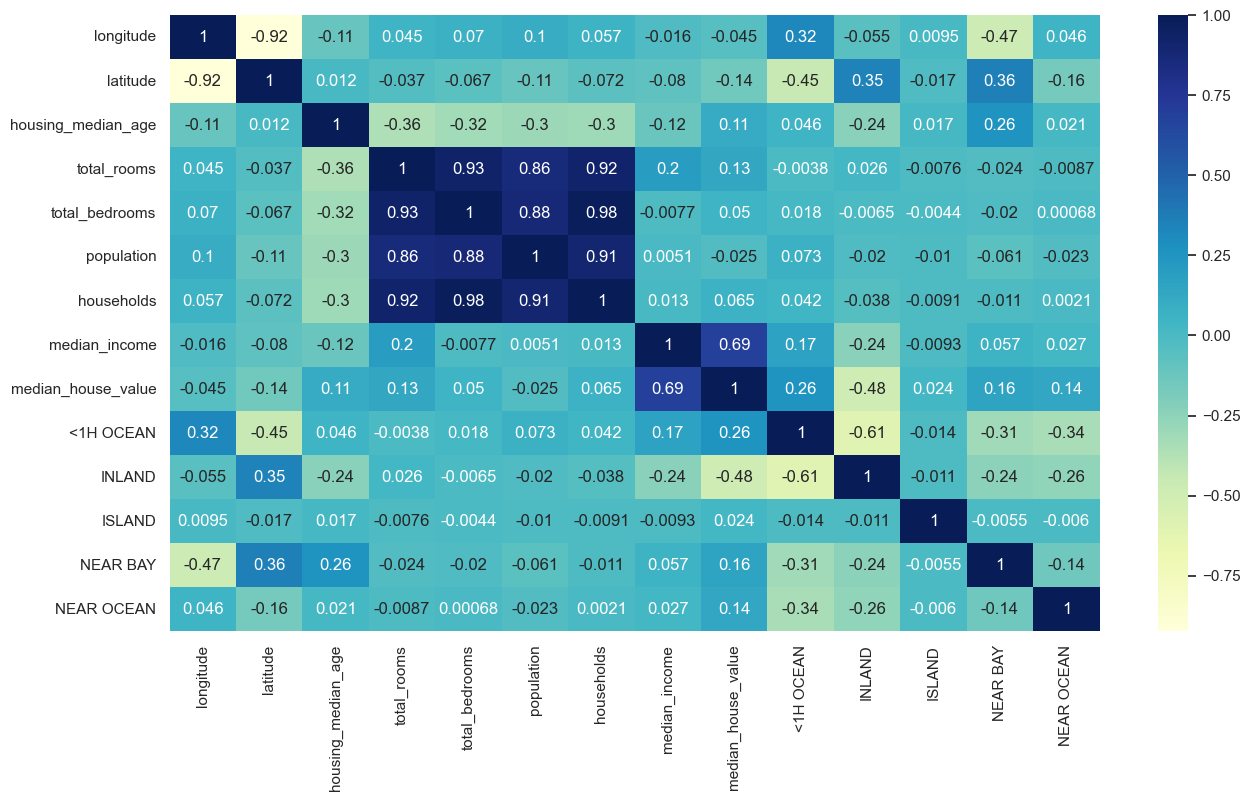

In [21]:
sb.set(rc={'figure.figsize':(15,8)})
sb.heatmap(data_na.corr(), annot=True, cmap='YlGnBu')

In [22]:
data_na.corr()["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688355
<1H OCEAN             0.257614
NEAR BAY              0.160526
NEAR OCEAN            0.140378
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
ISLAND                0.023525
population           -0.025300
longitude            -0.045398
latitude             -0.144638
INLAND               -0.484787
Name: median_house_value, dtype: float64

<Axes: xlabel='median_house_value', ylabel='median_income'>

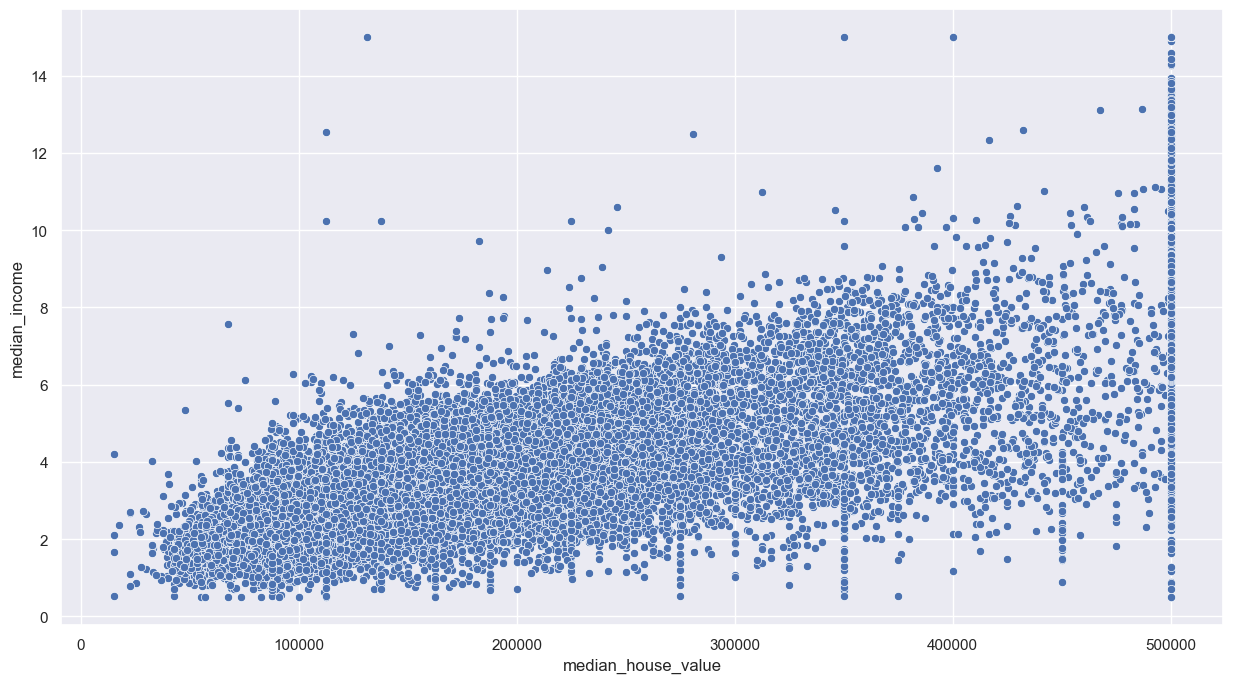

In [23]:
sb.scatterplot(x=data_na['median_house_value'], y=data_na['median_income'])

In [24]:
# Agregar nuevas características (features) al dataset
data_na['bedroom_ratio'] = data_na['total_bedrooms'] / data_na['total_rooms']

<Axes: >

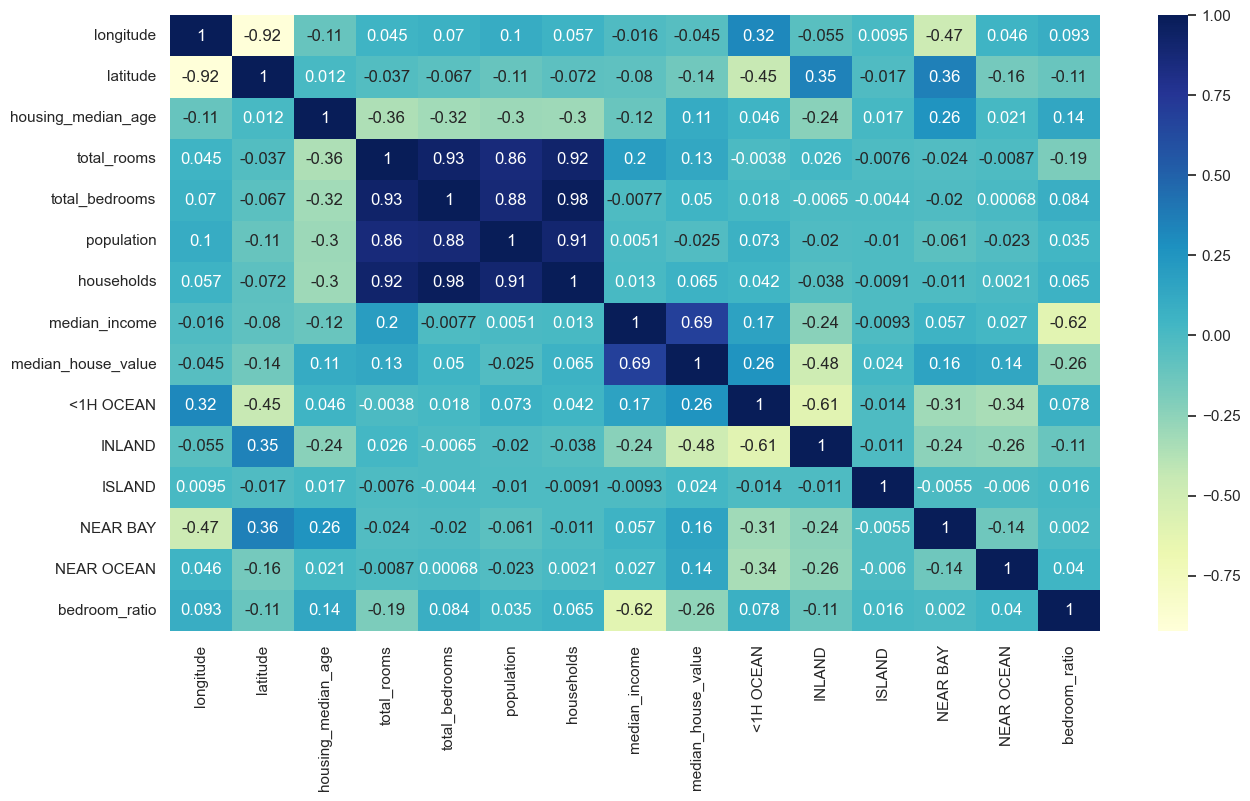

In [25]:
sb.set(rc={'figure.figsize':(15,8)})
sb.heatmap(data_na.corr(), annot=True, cmap='YlGnBu')

In [26]:
# Separar las características (features) de la etiqueta (label) que queremos predecir
X = data_na.drop('median_house_value', axis=1)
y = data_na['median_house_value']

In [27]:
# Separar los datos en 2 partes: Conjunto de entrenamiento (train) y uno de prueba (test)
from sklearn.model_selection import train_test_split

X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=.2)

In [28]:
X_ent.shape

(16346, 14)

In [29]:
y_ent.shape

(16346,)

In [30]:
X_pru.shape

(4087, 14)

In [31]:
y_pru.shape

(4087,)

# Crear modelo de regresión lineal

In [33]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

In [ ]:
# Entrenar el modelo con los datos de entrenamiento
modelo.fit(X_ent, y_ent)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Realizar predicción

In [36]:
predicciones = modelo.predict(X_pru)

In [37]:
comparacion = {'Prediccion': predicciones, 'Valor Real': y_pru}
pd.DataFrame(comparacion)

,Prediccion,Valor Real
15519,200849.240754,137500.0
15920,295877.263992,263200.0
18738,52889.339984,85200.0
11206,259772.308694,179300.0
15214,267864.768241,263600.0
...,...,...
19832,39470.321715,51800.0
9503,207595.979697,109400.0
14627,262250.524554,158900.0
10962,199895.160677,187500.0


In [38]:
# Overfitting (sobreajuste): Cuando el modelo se ajusta demasiado a los datos de entrenamiento y no generaliza bien a datos nuevos. Esto puede ocurrir cuando el modelo es demasiado complejo o cuando hay demasiadas características en relación con la cantidad de datos de entrenamiento.

print(modelo.score(X_ent, y_ent)) # R^2 score on training data
print(modelo.score(X_pru, y_pru)) # R^2 score on test data

0.650746995760493
0.6572216505939075


In [39]:
# Error cuadrático medio (MSE) y raíz del error cuadrático medio (RMSE)
from sklearn.metrics import mean_squared_error
import numpy as np

mse = mean_squared_error(y_pru, predicciones)

In [40]:
mse

4549916675.817766

In [41]:
rmse = np.sqrt(mse)

In [43]:
rmse

np.float64(67453.07017340105)

In [44]:
data_na.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155,0.442128,0.317917,0.000245,0.111095,0.128615,0.213039
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099,0.496652,0.465678,0.015641,0.314257,0.334782,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.100000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.203162
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_ent_esc = scaler.fit_transform(X_ent)
X_pru_esc = scaler.fit_transform(X_pru)

In [47]:
X_ent

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio
10913,-117.86,33.73,26.0,1702.0,456.0,2776.0,463.0,2.6385,1,0,0,0,0,0.267920
5935,-117.87,34.15,24.0,5745.0,735.0,2061.0,679.0,8.2827,0,1,0,0,0,0.127937
2599,-123.72,41.09,19.0,1970.0,431.0,1166.0,363.0,1.8208,1,0,0,0,0,0.218782
4067,-118.47,34.15,43.0,804.0,117.0,267.0,110.0,8.2269,1,0,0,0,0,0.145522
297,-122.17,37.76,47.0,2118.0,413.0,965.0,382.0,2.1842,0,0,0,1,0,0.194995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2178,-119.87,36.76,34.0,1649.0,323.0,919.0,316.0,2.8750,0,1,0,0,0,0.195876
7497,-118.25,33.93,42.0,763.0,191.0,754.0,174.0,2.0486,1,0,0,0,0,0.250328
5454,-118.46,34.00,36.0,1392.0,260.0,679.0,247.0,4.7344,1,0,0,0,0,0.186782
11438,-117.96,33.65,18.0,3603.0,879.0,1549.0,756.0,4.0229,1,0,0,0,0,0.243963


In [48]:
X_ent_esc

array([[ 0.85436906, -0.88935185, -0.2092827 , ..., -0.35221366,
        -0.38645321,  0.93770803],
       [ 0.84936951, -0.69284541, -0.36839595, ..., -0.35221366,
        -0.38645321, -1.46781332],
       [-2.0753659 ,  2.5541896 , -0.76617909, ..., -0.35221366,
        -0.38645321,  0.09329407],
       ...,
       [ 0.55439619, -0.76302628,  0.58628358, ..., -0.35221366,
        -0.38645321, -0.45660911],
       [ 0.80437358, -0.92678165, -0.84573572, ..., -0.35221366,
        -0.38645321,  0.52602571],
       [ 0.69438353, -0.46826662, -0.76617909, ..., -0.35221366,
        -0.38645321, -0.74277198]], shape=(16346, 14))

In [49]:
pd.DataFrame(X_ent_esc)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.854369,-0.889352,-0.209283,-0.429690,-0.195684,1.210988,-0.095185,-0.648944,1.123576,-0.681974,-0.015645,-0.352214,-0.386453,0.937708
1,0.849370,-0.692845,-0.368396,1.439116,0.472266,0.570738,0.475432,2.333726,-0.890016,1.466331,-0.015645,-0.352214,-0.386453,-1.467813
2,-2.075366,2.554190,-0.766179,-0.305812,-0.255536,-0.230695,-0.359360,-1.081056,1.123576,-0.681974,-0.015645,-0.352214,-0.386453,0.093294
3,0.549397,-0.692845,1.143180,-0.844775,-1.007280,-1.035710,-1.027721,2.304238,1.123576,-0.681974,-0.015645,-0.352214,-0.386453,-1.165625
4,-1.300436,0.996174,1.461406,-0.237402,-0.298630,-0.410682,-0.309167,-0.889018,-0.890016,-0.681974,-0.015645,2.839186,-0.386453,-0.315462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16341,-0.150540,0.528302,0.427170,-0.454189,-0.514098,-0.451873,-0.483522,-0.523966,-0.890016,1.466331,-0.015645,-0.352214,-0.386453,-0.300322
16342,0.659387,-0.795777,1.063623,-0.863727,-0.830117,-0.599623,-0.858650,-0.960676,1.123576,-0.681974,-0.015645,-0.352214,-0.386453,0.635392
16343,0.554396,-0.763026,0.586284,-0.572982,-0.664925,-0.666782,-0.665802,0.458632,1.123576,-0.681974,-0.015645,-0.352214,-0.386453,-0.456609
16344,0.804374,-0.926782,-0.845736,0.449014,0.817015,0.112264,0.678846,0.082640,1.123576,-0.681974,-0.015645,-0.352214,-0.386453,0.526026
